In [1]:
import numpy as np
import matplotlib.pyplot as plt
E_F = 12.2400  # Fermi energy in eV
def load_data(filename,up_index=2,down_index=3):

     # load data
     data = np.loadtxt(filename)

     E = np.unique(data[:, 1])
     k = np.unique(data[:, 0])

     dosup = np.zeros([len(k),len(E)])
     dosdown = np.zeros([len(k),len(E)])

     for i in range(len(data)):
         E_index = int(i % len(E))
         k_index = int(data[i][0] - 1)

         dosup[k_index, E_index] = data[i][up_index]
         dosdown[k_index, E_index] = data[i][down_index]
         if dosup[k_index, E_index]<0: dosup[k_index, E_index]=0
         if dosdown[k_index, E_index]<0: dosdown[k_index, E_index]=0

     return k,E,dosup,dosdown


In [2]:
k, E, DoStotalup, DoStotaldown = load_data('Ru_pdos.k.dat.pdos_tot')


k,E,DoSRu1up, DoSRu1down= load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)')
k,E,DoSRu2up, DoSRu2down = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)')

DoSRuup = DoSRu1up + DoSRu2up
DoSRudown = DoSRu1down + DoSRu2down

k,E,DoSO1up, DoSO1down = load_data('Ru_pdos.k.dat.pdos_atm#3(O)_wfc#2(p)')
k,E,DoSO2up, DoSO2down = load_data('Ru_pdos.k.dat.pdos_atm#4(O)_wfc#2(p)')
k,E,DoSO3up, DoSO3down = load_data('Ru_pdos.k.dat.pdos_atm#5(O)_wfc#2(p)')
k,E,DoSO4up, DoSO4down = load_data('Ru_pdos.k.dat.pdos_atm#6(O)_wfc#2(p)')
DoSOup = DoSO1up + DoSO2up + DoSO3up + DoSO4up
DoSOdown = DoSO1down + DoSO2down + DoSO3down + DoSO4down

k, E, DoSRu1dz2up, DoSRu1dz2down = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=4, down_index=5)
k, E, DoSRu2dz2up, DoSRu2dz2down = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=4, down_index=5)
DoSRudz2up = DoSRu1dz2up + DoSRu2dz2up
DoSRudz2down = DoSRu1dz2down + DoSRu2dz2down


k, E, DoSRu1dzxup, DoSRu1dzxdown = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=6, down_index=7)
k, E, DoSRu2dzxup, DoSRu2dzxdown = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=6, down_index=7)
DoSRudzxup = DoSRu1dzxup + DoSRu2dzxup
DoSRudzxdown = DoSRu1dzxdown + DoSRu2dzxdown


k, E, DoSRu1dzyup, DoSRu1dzydown = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=8, down_index=9)
k, E, DoSRu2dzyup, DoSRu2dzydown = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=8, down_index=9)
DoSRudzyup = DoSRu1dzyup + DoSRu2dzyup
DoSRudzydown = DoSRu1dzydown + DoSRu2dzydown


k, E, DoSRu1dx2y2up, DoSRu1dx2y2down = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=10, down_index=11)
k, E, DoSRu2dx2y2up, DoSRu2dx2y2down = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=10, down_index=11)
DoSRudx2y2up = DoSRu1dx2y2up + DoSRu2dx2y2up
DoSRudx2y2down = DoSRu1dx2y2down + DoSRu2dx2y2down


k, E, DoSRu1dxyup, DoSRu1dxydown = load_data('Ru_pdos.k.dat.pdos_atm#1(Ru1)_wfc#4(d)', up_index=12, down_index=13)
k, E, DoSRu2dxyup, DoSRu2dxydown = load_data('Ru_pdos.k.dat.pdos_atm#2(Ru2)_wfc#4(d)', up_index=12, down_index=13)
DoSRudxyup = DoSRu1dxyup + DoSRu2dxyup
DoSRudxydown = DoSRu1dxydown + DoSRu2dxydown



In [3]:
xtik = np.array([0.0000, 0.5000 ,1.2248, 1.7248, 2.4496, 3.1567, 3.8814 , 4.5886]) * len(k)/ 4.5886
xtiklabel = np.array(['$\Gamma$', 'X', 'R', 'Z', '$\Gamma$', 'M', 'A', 'Z'])
# Calculate the relative projected DoS of Ru d orbitals with respect to the total DoS
with np.errstate(divide='ignore', invalid='ignore'):
    totalDoS = DoStotalup + DoStotaldown
    totalDoSup   = np.where(DoStotalup != 0, DoStotalup, 0.000001)  # Avoid division by zero
    totalDoSdown = np.where(DoStotaldown != 0, DoStotaldown, 0.01)  # Avoid division by zero
    DoSRuup_rel = DoSRuup / np.max(totalDoSup )
    DoSRudown_rel = DoSRudown / np.max(DoStotaldown )

    DoSOup_rel = DoSOup / np.max(DoStotalup)
    DoSOdown_rel = DoSOdown / np.max(DoStotaldown)

    DoSRudz2up_rel   = DoSRudz2up / np.max(totalDoSup )
    DoSRudz2down_rel = DoSRudz2down / np.max(DoStotaldown)

    DoSRudzxup_rel   = DoSRudzxup / np.max(totalDoSup )
    DoSRudzxdown_rel = DoSRudzxdown / np.max(DoStotaldown)

    DoSRudzyup_rel   = DoSRudzyup / np.max(totalDoSup )
    DoSRudzydown_rel = DoSRudzydown / np.max(DoStotaldown)

    DoSRudx2y2up_rel   = DoSRudx2y2up / np.max(totalDoSup )
    DoSRudx2y2down_rel = DoSRudx2y2down / np.max(DoStotaldown)

    DoSRudxyup_rel   = DoSRudxyup / np.max(totalDoSup )
    DoSRudxydown_rel = DoSRudxydown / np.max(DoStotaldown)

<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_32596\2568407123.py:2: SyntaxWarning: invalid escape sequence '\G'
  xtiklabel = np.array(['$\Gamma$', 'X', 'R', 'Z', '$\Gamma$', 'M', 'A', 'Z'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_32596\2568407123.py:2: SyntaxWarning: invalid escape sequence '\G'
  xtiklabel = np.array(['$\Gamma$', 'X', 'R', 'Z', '$\Gamma$', 'M', 'A', 'Z'])


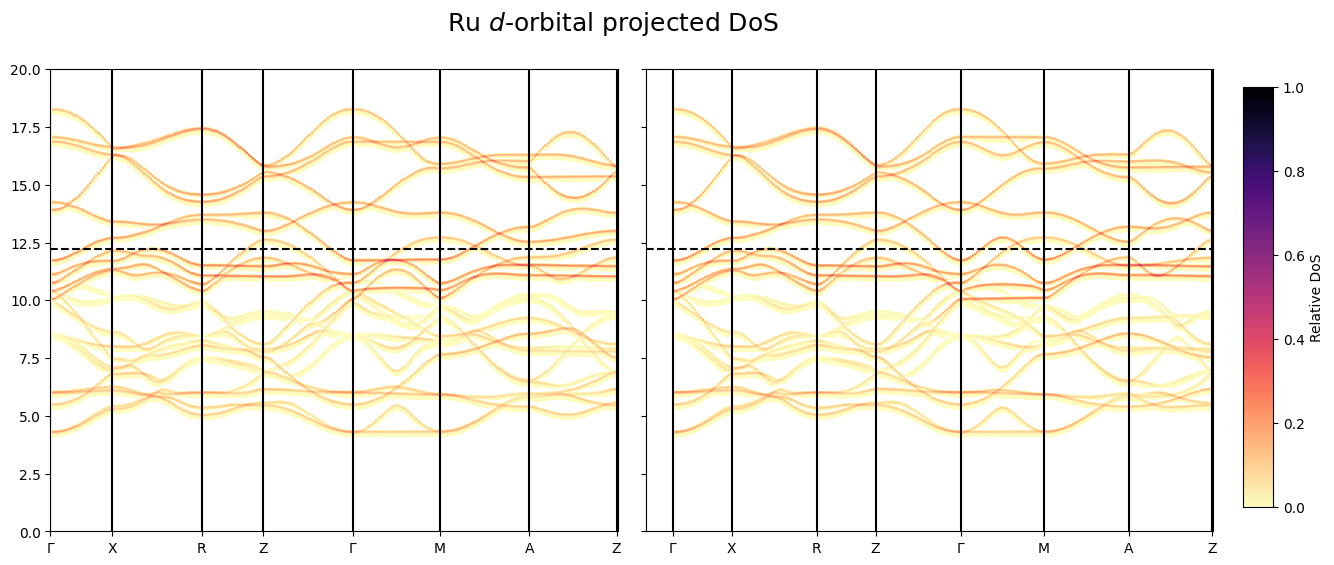

In [4]:
cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Up spin
band_mask = DoSRuup_rel < 1e-7
DoSRuup_masked = np.ma.masked_where(band_mask, DoSRuup_rel)
ax[0].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0, 20)
im0 = ax[0].pcolormesh(k, E, DoSRuup_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for xt in xtik:
    ax[0].axvline(x=xt, color='black', linestyle='-')
    ax[1].axvline(x=xt, color='black', linestyle='-')

# Down spin
band_mask = DoSRudown_rel < 1e-7
DoSRudown_masked = np.ma.masked_where(band_mask, DoSRudown_rel)
im1 = ax[1].pcolormesh(k, E, DoSRudown_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[1].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)

# Move colorbar outside second plot
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im1, cax=cbar_ax, label='Relative DoS')

fig.suptitle('Ru $d$-orbital projected DoS', fontsize=18)
plt.subplots_adjust(wspace=0.05)  # small gap between subplots
plt.show()

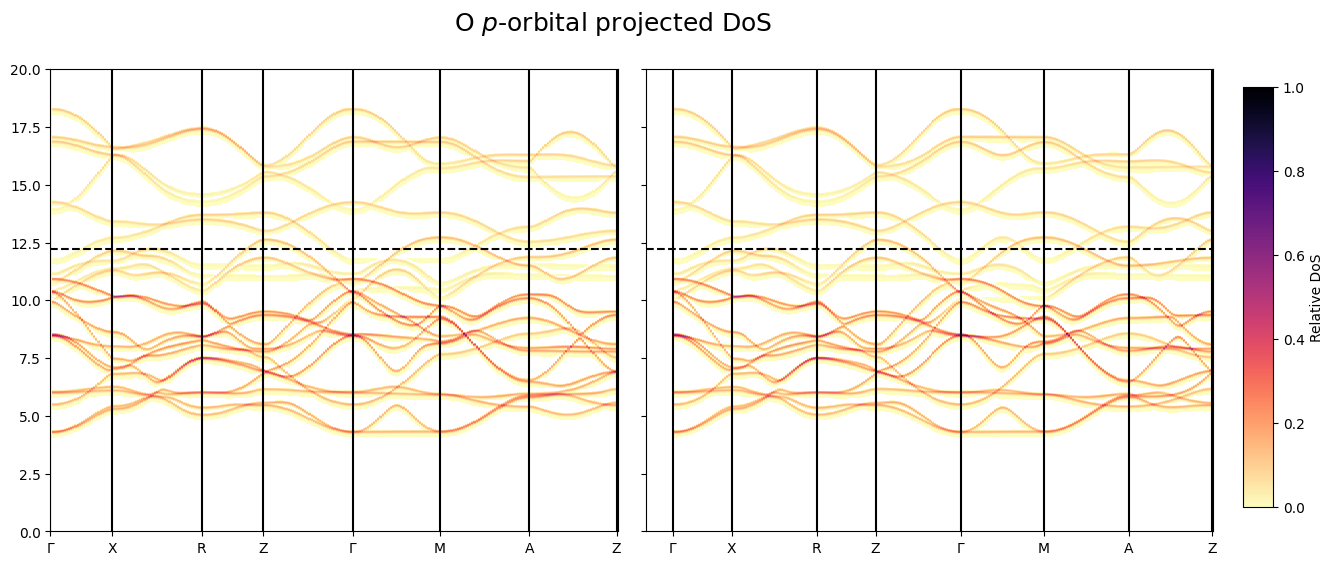

In [5]:
cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Up spin
band_mask = DoSOup_rel < 1e-7
DoSOup_masked = np.ma.masked_where(band_mask, DoSOup_rel)
ax[0].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[0].set_ylim(0, 20)
im0 = ax[0].pcolormesh(k, E, DoSOup_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
for xt in xtik:
    ax[0].axvline(x=xt, color='black', linestyle='-')
    ax[1].axvline(x=xt, color='black', linestyle='-')

# Down spin
band_mask = DoSOdown_rel < 1e-7
DoSOdown_masked = np.ma.masked_where(band_mask, DoSOdown_rel)
im1 = ax[1].pcolormesh(k, E, DoSOdown_masked.T, cmap=cmr, vmin=0, vmax=1)
ax[1].axhline(y=E_F, label='Fermi level', color='black', linestyle='--')
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)

# Move colorbar outside second plot
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(im1, cax=cbar_ax, label='Relative DoS')

fig.suptitle('O $p$-orbital projected DoS', fontsize=18)
plt.subplots_adjust(wspace=0.05)  # small gap between subplots
plt.show()


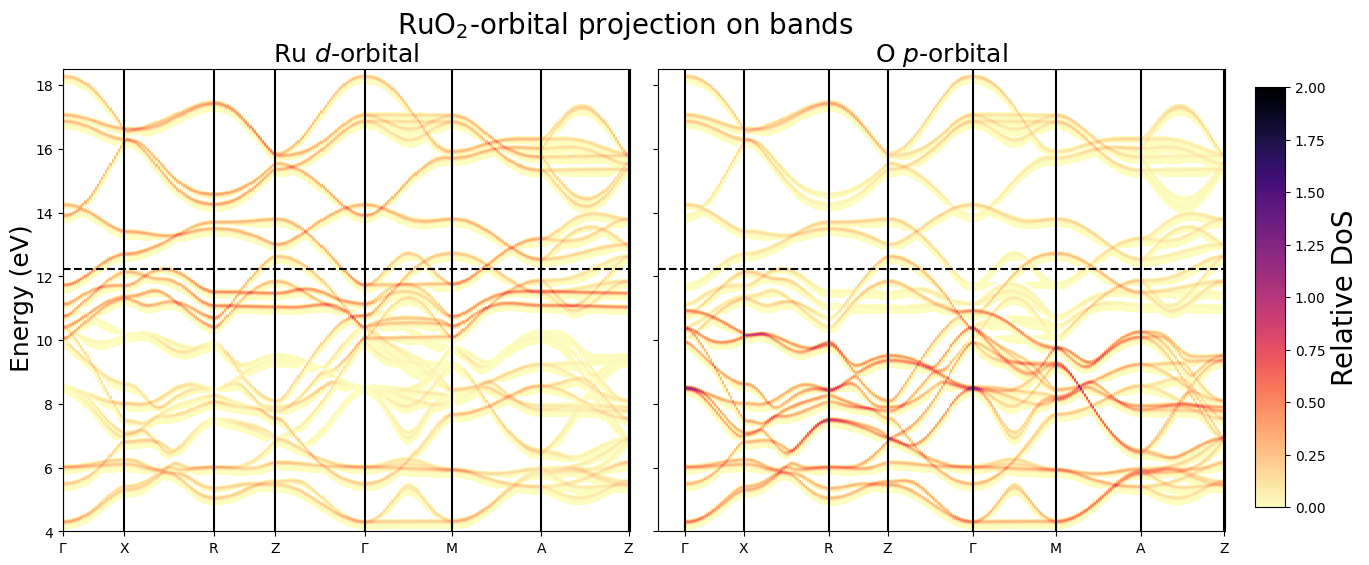

In [11]:
import matplotlib.font_manager as fm
cmr = plt.cm.magma_r
cmr.set_bad(color='white')
fig, ax = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

DoSO_rel = DoSOup_rel + DoSOdown_rel
DoSRu_rel = DoSRuup_rel + DoSRudown_rel

# Ru d-orbitals
band_mask = DoSRu_rel < 1e-7
DoSRu_masked = np.ma.masked_where(band_mask, DoSRu_rel)
ax[0].axhline(y=E_F, color='black', linestyle='--')
ax[0].set_ylim(4, 18.5)
im0 = ax[0].pcolormesh(k, E, DoSRu_masked.T, cmap=cmr, vmin=0, vmax=2)
ax[0].set_xticks(xtik)
ax[0].set_xticklabels(xtiklabel)
ax[0].set_title('Ru $d$-orbital', fontsize=18)
for xt in xtik:
    ax[0].axvline(x=xt, color='black', linestyle='-')
    ax[1].axvline(x=xt, color='black', linestyle='-')

# O p-orbitals
band_mask = DoSO_rel < 1e-7
DoSO_masked = np.ma.masked_where(band_mask, DoSO_rel)
ax[1].axhline(y=E_F, color='black', linestyle='--')
im1 = ax[1].pcolormesh(k, E, DoSO_masked.T, cmap=cmr, vmin=0, vmax=2)
ax[1].set_xticks(xtik)
ax[1].set_xticklabels(xtiklabel)
ax[1].set_title('O $p$-orbital', fontsize=18)

# Place colorbar to the right of the second plot
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label('Relative DoS', fontsize=20)

fig.suptitle('RuO$_2$-orbital projection on bands', fontsize=20)
fig.text(0.09, 0.5, 'Energy (eV)', va='center', rotation='vertical', fontsize=18)
plt.subplots_adjust(wspace=0.05)  # reduce space between plots
plt.savefig('RuO2_orbital_projected_DOS.png', dpi=300, bbox_inches='tight')